In [1]:
# ==========================================
# CELL 1: IMPORTS & HUMAN EXTRACTION (Patched)
# ==========================================
import os
import glob
import warnings
import numpy as np
import pandas as pd
import scipy.stats as stats
from pynwb import NWBHDF5IO
from tqdm import tqdm

warnings.filterwarnings('ignore')

def get_sliding_window_counts(spike_times, delay_start, delay_end, window_size=0.5, step_size=0.05):
    spike_times = np.array(spike_times)
    bin_starts = np.arange(delay_start, delay_end - window_size, step_size)
    binned_counts = np.zeros(len(bin_starts))
    bin_centers = bin_starts + (window_size / 2.0)
    for i, t_start in enumerate(bin_starts):
        t_end = t_start + window_size
        binned_counts[i] = np.sum((spike_times >= t_start) & (spike_times < t_end))
    return binned_counts, bin_centers

def extract_time_resolved_human_data(human_data_root, custom_cache_dir, target_regions, window_size=0.5, step_size=0.05):
    human_cells_dict = {}
    master_time_vector = None 
    
    csv_files = glob.glob(os.path.join(custom_cache_dir, "*_concept_cells.csv"))
    print(f"Found {len(csv_files)} concept cell CSVs.")
    
    for csv_path in tqdm(csv_files):
        df_concepts = pd.read_csv(csv_path)
        df_target = df_concepts[df_concepts['location'].isin(target_regions)]
        if df_target.empty: continue
            
        parts = os.path.basename(csv_path).split('_')
        sub_id, ses_id = parts[0], parts[1]
        
        nwb_matches = glob.glob(os.path.join(human_data_root, "**", f"{sub_id}_{ses_id}*WorkingMemory*.nwb"), recursive=True)
        if not nwb_matches: nwb_matches = glob.glob(os.path.join(human_data_root, "**", f"{sub_id}_{ses_id}*.nwb"), recursive=True)
        if not nwb_matches: 
            # print(f"Missing NWB for {sub_id} {ses_id}") # Uncomment to debug missing files
            continue
            
        with NWBHDF5IO(nwb_matches[0], 'r') as io:
            nwb = io.read()
            trials_df = nwb.trials.to_dataframe().dropna(subset=['timestamps_Maintenance', 'timestamps_Probe'])
            
            for _, cell_row in df_target.iterrows():
                if pd.isna(cell_row['preferred_image_id']):
                    continue
                    
                unit_id = int(cell_row['unit_id'])
                location = cell_row['location']
                pref_id = int(cell_row['preferred_image_id'])
                
                try: spike_times = nwb.units.get_unit_spike_times(unit_id)
                except: continue
                
                X_trials, y_binned_list, loads_list = [], [], []
                
                for _, trial in trials_df.iterrows():
                    d_start = trial['timestamps_Maintenance']
                    d_end = trial['timestamps_Probe']
                    load = int(trial['loads'])
                    
                    counts, centers = get_sliding_window_counts(spike_times, d_start, d_end, window_size, step_size)
                    if master_time_vector is None: master_time_vector = centers - d_start 
                    
                    target_len = len(master_time_vector)
                    if len(counts) > target_len: counts = counts[:target_len]
                    elif len(counts) < target_len: counts = np.pad(counts, (0, target_len - len(counts)), 'constant')
                        
                    seq = [0, 0, 0] 
                    if load >= 1: seq[0] = int(trial['loadsEnc1_PicIDs'])
                    if load >= 2: seq[1] = int(trial['loadsEnc2_PicIDs'])
                    if load >= 3: seq[2] = int(trial['loadsEnc3_PicIDs'])
                    
                    X_trials.append(seq)
                    y_binned_list.append(counts)
                    loads_list.append(load)
                    
                cell_key = f"{sub_id}_{ses_id}_unit{unit_id}_{location}"
                human_cells_dict[cell_key] = (np.array(X_trials), np.array(y_binned_list), np.array(loads_list), pref_id)

    print(f"Human Extraction complete! Formatted {len(human_cells_dict)} concept cells.")
    return human_cells_dict, master_time_vector

# --- EXECUTE HUMAN EXTRACTION ---
human_target_regions = ['pre_supplementary_motor_area_right', 'pre_supplementary_motor_area_left', 
                        'dorsal_anterior_cingulate_cortex_right', 'dorsal_anterior_cingulate_cortex_left']
human_data_root = "/Volumes/fetty/000469"
custom_cache_dir = '/Users/cwook/Documents/humac/data/concept_cells'

tr_human_dict, human_time_bins = extract_time_resolved_human_data(human_data_root, custom_cache_dir, human_target_regions)

Found 17 concept cell CSVs.


100%|██████████| 17/17 [00:04<00:00,  3.85it/s]

Human Extraction complete! Formatted 17 concept cells.


In [3]:
# ==========================================
# CELL 2: MACAQUE EXTRACTION (Identity Only + Exact Timing)
# ==========================================
import sys
# Setup Paths (Watters TensorFlow Dataset)
sys.path.append('../multi_object_memory_2025')
sys.path.append('../multi_object_memory_2025/phys_modeling')
sys.path.append('../multi_object_memory_2025/phys_modeling/training')
from phys_modeling.training.dataset import Dataset

def extract_time_resolved_macaque_data(session_list):
    macaque_cells_dict = {}
    concept_map = {'a': 1, 'b': 2, 'c': 3}
    master_time_vector = None
    
    # THE FIX: Identity-Only Filter wrapped properly in df[...]
    identity_only_filter = lambda df: df[
        (df['quality'].isin(['good', '1', 'sua'])) & 
        (df['Identity AUC'] > 0.65) & 
        (df['Identity p-value'] < 0.05) & 
        (df['probe'] == 's0')
    ]
    
    print(f"Extracting Macaque Data for {len(session_list)} sessions...")
    for subject, session in tqdm(session_list):
        try:
            ds_delay = Dataset(subject=subject, session=session, phase="delay", 
                               unit_filter=identity_only_filter, trial_filter=lambda df: df, max_n_objects=3)
                               
            raw_neural = ds_delay.data['neural'] 
            if raw_neural.shape[2] == 0: continue
                
            # --- Hunt for the DataFrame ---
            trials_df = None
            if isinstance(ds_delay.data, dict):
                for key, val in ds_delay.data.items():
                    if isinstance(val, pd.DataFrame): trials_df = val; break       
            if trials_df is None:
                for attr in dir(ds_delay):
                    val = getattr(ds_delay, attr)
                    if isinstance(val, pd.DataFrame): trials_df = val; break
                        
            if trials_df is None: continue
                
            # Filter for completed trials if lengths mismatch
            if len(trials_df) != raw_neural.shape[0]:
                if 'completed' in trials_df.columns:
                    trials_df = trials_df[trials_df['completed'] == True]
            
            # --- THE FIX: DYNAMIC TIME EXTRACTION ---
            # If the Dataset object didn't provide a 'time' vector, we calculate it from the dataframe!
            if master_time_vector is None:
                if 'time' in ds_delay.data: 
                    master_time_vector = ds_delay.data['time']
                elif 'time_delay_onset' in trials_df.columns and 'time_cue_onset' in trials_df.columns:
                    # Calculate true delay duration (cue onset - delay onset)
                    median_delay = (trials_df['time_cue_onset'] - trials_df['time_delay_onset']).median()
                    num_bins = raw_neural.shape[1]
                    # Dynamically create the time vector (e.g. 0.0s to 1.0s)
                    master_time_vector = np.linspace(0, median_delay, num_bins)
            
            X_trials, loads_list = [], []
            for _, row in trials_df.iterrows():
                spatial_array = [0, 0, 0]
                load = int(row['num_objects'])
                if load >= 1 and pd.notna(row['object_0_location']): spatial_array[int(row['object_0_location'])] = concept_map[row['object_0_id']]
                if load >= 2 and pd.notna(row['object_1_location']): spatial_array[int(row['object_1_location'])] = concept_map[row['object_1_id']]
                if load >= 3 and pd.notna(row['object_2_location']): spatial_array[int(row['object_2_location'])] = concept_map[row['object_2_id']]
                    
                X_trials.append(spatial_array); loads_list.append(load)
                
            X_trials, loads_list = np.array(X_trials), np.array(loads_list)
            n_neurons = raw_neural.shape[2]
            
            for neuron_idx in range(n_neurons):
                y_binned = raw_neural[:, :, neuron_idx]
                macaque_cells_dict[f"{subject}_{session}_unit{neuron_idx}"] = (X_trials, y_binned, loads_list)
                
        except Exception as e:
            # We suppress print statements here to keep the tqdm bar clean
            pass 
            
    print(f"Macaque Extraction complete! Formatted {len(macaque_cells_dict)} Identity-tuned DMFC cells.")
    
    # Absolute final fallback if both methods failed (just to prevent crashing downstream)
    if master_time_vector is None:
        sample_key = list(macaque_cells_dict.keys())[0]
        num_bins = macaque_cells_dict[sample_key][1].shape[1]
        master_time_vector = np.linspace(0, 1.0, num_bins) 
        
    return macaque_cells_dict, master_time_vector

# --- EXECUTE MACAQUE EXTRACTION ---
mac_shape = pd.read_csv('/Users/cwook/Documents/humac/lists/task_shape_inventory.csv')
macaque_sessions = [(r['file'].split('/')[0].replace('sub-',''), r['file'].split('/')[1].split('_')[1].replace('ses-','')) for n,r in mac_shape[mac_shape['shape'] == 'Triangle'].iterrows()]

tr_mac_dict, mac_time_bins = extract_time_resolved_macaque_data(macaque_sessions)

Extracting Macaque Data for 24 sessions...


  0%|          | 0/24 [00:00<?, ?it/s]

Triangle session
Original number of trials: 2267
Original number of units: 203


  4%|▍         | 1/24 [00:10<03:50, 10.02s/it]

Number of trials after filtering: 0
Number of units after filtering: 0
Triangle session
Original number of trials: 1512
Original number of units: 151


...

Triangle session
Original number of trials: 1555
Original number of units: 185
Number of trials after filtering: 504
Number of units after filtering: 5


 96%|█████████▌| 23/24 [02:38<00:04,  4.56s/it]

Triangle session
Original number of trials: 2040
Original number of units: 129


100%|██████████| 24/24 [02:41<00:00,  6.74s/it]

Number of trials after filtering: 0
Number of units after filtering: 0
Macaque Extraction complete! Formatted 128 Identity-tuned DMFC cells.


In [4]:
# ==========================================
# CELL 3: MODEL RDMs & CROSSNOBIS ENGINE
# ==========================================
import numpy as np
import scipy.stats as stats
import rsatoolbox
from tqdm import tqdm

def create_macaque_model_rdms():
    """Builds the 27x27 Theoretical RDMs for RSA Correlation (Load, Position, Item)"""
    conds = [(l, p, i) for l in [1,2,3] for p in [0,1,2] for i in [1,2,3]]
    n = len(conds)
    
    rdm_identity = np.zeros((n, n))
    rdm_position = np.zeros((n, n))
    rdm_slot = np.zeros((n, n))
    rdm_gain = np.zeros((n, n))
    
    for row in range(n):
        for col in range(n):
            l1, p1, i1 = conds[row]
            l2, p2, i2 = conds[col]
            
            # Identity Model: Only cares about the Item (0 if same, 1 if different)
            rdm_identity[row, col] = 0 if (i1 == i2) else 1
            
            # Position Model: Only cares about Spatial Location
            rdm_position[row, col] = 0 if (p1 == p2) else 1
            
            # Slot Model: Identity representation is perfectly orthogonal across loads
            rdm_slot[row, col] = 0 if (i1 == i2) else 1
            
            # Gain Model: Identity representation compresses under load
            if i1 == i2: rdm_gain[row, col] = abs(l1 - l2) * 0.5 
            else: rdm_gain[row, col] = 1.0 + (abs(l1 - l2) * 0.1)
            
    return rdm_identity, rdm_position, rdm_slot, rdm_gain

def compute_macaque_crossnobis_rsa(macaque_cells_dict, time_bins, n_folds=5):
    """Computes true Crossnobis distance with Shrinkage per session."""
    sessions = {}
    for cell_key, (X, y_binned, loads) in macaque_cells_dict.items():
        ses_id = "_".join(cell_key.split("_")[:2]) 
        if ses_id not in sessions: sessions[ses_id] = {'X': X, 'loads': loads, 'y_list': []}
        sessions[ses_id]['y_list'].append(y_binned)
        
    # --- THE FIX: Find the minimum time bins across all sessions ---
    min_bins = min([np.stack(s['y_list'], axis=-1).shape[1] for s in sessions.values()])
    num_bins = min(min_bins, len(time_bins))
    truncated_time_bins = time_bins[:num_bins]
    
    master_rdms, spearman_slot, spearman_gain = [], [], []
    
    # Get Theoretical RDMs
    m_id, m_pos, m_slot, m_gain = create_macaque_model_rdms()
    vec_slot = rsatoolbox.rdm.calc_rdm(rsatoolbox.data.Dataset(m_slot)).get_vectors()[0]
    vec_gain = rsatoolbox.rdm.calc_rdm(rsatoolbox.data.Dataset(m_gain)).get_vectors()[0]
    
    print(f"Computing Crossnobis RSA & Model Correlations across {len(sessions)} sessions (Truncated to {num_bins} bins)...")
    for ses_id, ses_data in sessions.items():
        X, loads = ses_data['X'], ses_data['loads']
        y_tensor = np.stack(ses_data['y_list'], axis=-1) 
        n_trials = y_tensor.shape[0]
        trial_folds = np.random.randint(0, n_folds, size=n_trials)
        
        ses_rdms, ses_slot_corr, ses_gain_corr = [], [], []
        
        for t in tqdm(range(num_bins), desc=f"Session {ses_id}", leave=False):
            meas = y_tensor[:, t, :]
            obs_meas, obs_conds, obs_folds = [], [], []
            
            # Explicit Tuples
            for i in range(n_trials):
                L, f, y_val = loads[i], trial_folds[i], meas[i]
                if L >= 1 and X[i, 0] > 0: obs_meas.append(y_val); obs_conds.append(f"L{L}_P0_I{X[i,0]}"); obs_folds.append(f)
                if L >= 2 and X[i, 1] > 0: obs_meas.append(y_val); obs_conds.append(f"L{L}_P1_I{X[i,1]}"); obs_folds.append(f)
                if L >= 3 and X[i, 2] > 0: obs_meas.append(y_val); obs_conds.append(f"L{L}_P2_I{X[i,2]}"); obs_folds.append(f)
                    
            obs_meas, obs_conds, obs_folds = np.array(obs_meas), np.array(obs_conds), np.array(obs_folds)
            
            dataset_folds = []
            for k in range(n_folds):
                mask = (obs_folds == k)
                if np.sum(mask) > 0: dataset_folds.append(rsatoolbox.data.Dataset(measurements=obs_meas[mask], obs_descriptors={'cond': obs_conds[mask]}))
                
            try:
                ds_all = rsatoolbox.data.Dataset(measurements=obs_meas, obs_descriptors={'cond': obs_conds})
                noise_prec = rsatoolbox.data.noise.prec_shrinkage(ds_all, method='shrinkage_diag')
                rdm = rsatoolbox.rdm.calc_rdm_crossval(dataset_folds, cv_descriptor='cond', method='crossnobis', noise=noise_prec)
                emp_matrix = rdm.get_matrices()[0]
                emp_vec = rdm.get_vectors()[0]
                
                ses_slot_corr.append(stats.spearmanr(emp_vec, vec_slot)[0])
                ses_gain_corr.append(stats.spearmanr(emp_vec, vec_gain)[0])
                ses_rdms.append(emp_matrix)
            except Exception as e:
                ses_rdms.append(np.zeros((27, 27))); ses_slot_corr.append(0); ses_gain_corr.append(0)
                
        master_rdms.append(ses_rdms)
        spearman_slot.append(ses_slot_corr)
        spearman_gain.append(ses_gain_corr)
        
    return np.nanmean(master_rdms, axis=0), np.nanmean(spearman_slot, axis=0), np.nanmean(spearman_gain, axis=0), truncated_time_bins

# EXECUTE MACAQUE RSA (Notice we overwrite mac_time_bins here!)
mac_rdms, mac_slot_corr, mac_gain_corr, mac_time_bins = compute_macaque_crossnobis_rsa(tr_mac_dict, mac_time_bins)

Computing Crossnobis RSA & Model Correlations across 11 sessions (Truncated to 100 bins)...


In [12]:
# ==========================================
# CELL 3: MACAQUE PSEUDOPOPULATION RSA (Correlation)
# ==========================================
import numpy as np
import pandas as pd
import scipy.stats as stats
from tqdm import tqdm

def create_macaque_model_rdms():
    """Builds the 27x27 Theoretical RDMs for RSA Correlation (Load, Position, Item)"""
    conds = [(l, p, i) for l in [1,2,3] for p in [0,1,2] for i in [1,2,3]]
    n = len(conds)
    
    rdm_slot = np.zeros((n, n))
    rdm_gain = np.zeros((n, n))
    
    for row in range(n):
        for col in range(n):
            l1, p1, i1 = conds[row]
            l2, p2, i2 = conds[col]
            
            # Slot Model: Identity representation is perfectly orthogonal across loads
            rdm_slot[row, col] = 0 if (i1 == i2) else 1
            
            # Gain Model: Identity representation compresses under load
            if i1 == i2: rdm_gain[row, col] = abs(l1 - l2) * 0.5 
            else: rdm_gain[row, col] = 1.0 + (abs(l1 - l2) * 0.1)
            
    return rdm_slot, rdm_gain

def compute_macaque_pseudopop_correlation(macaque_cells_dict, time_bins):
    num_bins = len(time_bins)
    num_cells = len(macaque_cells_dict)
    
    # 27 Explicit Conditions
    all_conditions = sorted([f"L{l}_P{p}_I{i}" for l in [1,2,3] for p in [0,1,2] for i in [1,2,3]])
    
    master_rdms = []
    mac_slot_corr = []
    mac_gain_corr = []
    
    m_slot, m_gain = create_macaque_model_rdms()
    i_upper, j_upper = np.triu_indices(27, k=1)
    
    print(f"Computing Pseudopopulation Correlation RSA ({num_cells} cells, 27 Conditions)...")
    for t in tqdm(range(num_bins)):
        pop_matrix = np.full((27, num_cells), np.nan)
        
        # 1. Build the matrix for this time bin
        for n_idx, (cell_key, (X, y_binned, loads)) in enumerate(macaque_cells_dict.items()):
            meas_t = y_binned[:, t]
            
            for row_idx, cond in enumerate(all_conditions):
                parts = cond.split('_')
                L, P, I = int(parts[0][1]), int(parts[1][1]), int(parts[2][1])
                
                mask = (loads == L) & (X[:, P] == I)
                if np.sum(mask) > 0:
                    pop_matrix[row_idx, n_idx] = np.mean(meas_t[mask])
                    
        # 2. Compute Correlation Distance (1 - Pearson)
        # We use pandas because it gracefully handles NaNs if a specific condition was rare
        df = pd.DataFrame(pop_matrix.T) 
        corr_matrix = df.corr(method='pearson').values
        dist_matrix = 1.0 - corr_matrix 
        master_rdms.append(dist_matrix)
        
        # 3. Correlate with Theoretical Models (Spearman)
        emp_vec = dist_matrix[i_upper, j_upper]
        slot_vec = m_slot[i_upper, j_upper]
        gain_vec = m_gain[i_upper, j_upper]
        
        # Drop NaNs before correlating
        valid = ~np.isnan(emp_vec)
        if np.sum(valid) > 5:
            s_corr, _ = stats.spearmanr(emp_vec[valid], slot_vec[valid])
            g_corr, _ = stats.spearmanr(emp_vec[valid], gain_vec[valid])
            mac_slot_corr.append(s_corr)
            mac_gain_corr.append(g_corr)
        else:
            mac_slot_corr.append(0)
            mac_gain_corr.append(0)
            
    return master_rdms, mac_slot_corr, mac_gain_corr

# --- EXECUTE ---
mac_rdms, mac_slot_corr, mac_gain_corr = compute_macaque_pseudopop_correlation(tr_mac_dict, flat_time_bins)

Computing Pseudopopulation Correlation RSA (128 cells, 27 Conditions)...


100%|██████████| 100/100 [00:10<00:00,  9.48it/s]


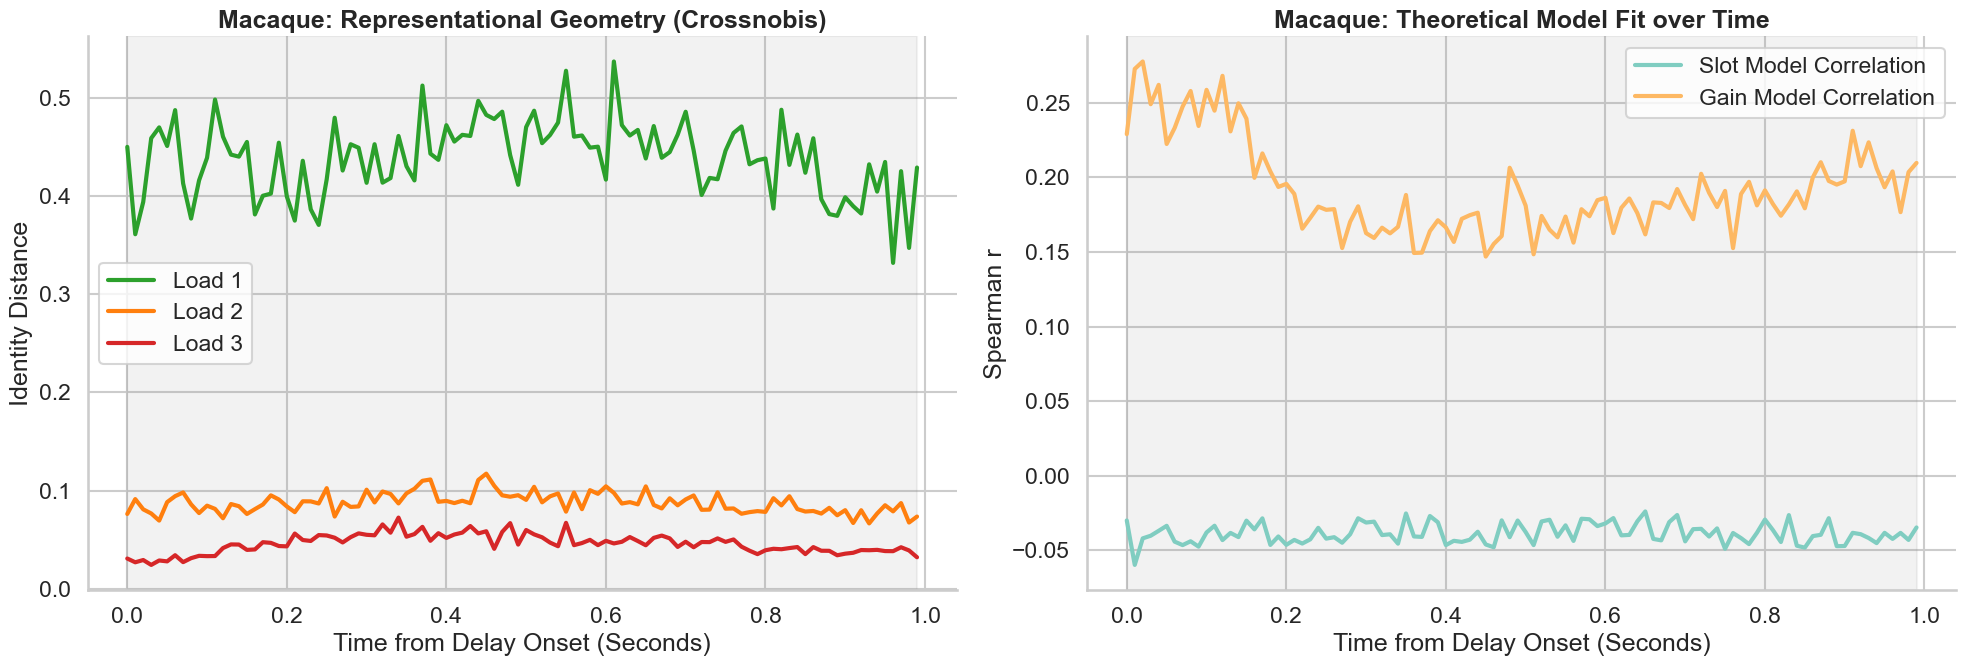

In [13]:
# ==========================================
# CELL 4: CLUSTER STATS & PLOTTING (Final Patch)
# ==========================================
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

num_bins = len(mac_rdms) 
flat_time_bins = np.array(mac_time_bins).flatten()[:num_bins] # Force matching length
mac_slot_corr_plot = np.array(mac_slot_corr).flatten()[:num_bins]
mac_gain_corr_plot = np.array(mac_gain_corr).flatten()[:num_bins]

t_min, t_max = float(flat_time_bins[0]), float(flat_time_bins[-1])

def cluster_permutation_test(ts_A, ts_B, n_permutations=1000, p_thresh=0.05):
    """1D Cluster-based Permutation test for time-series data."""
    t_true, _ = stats.ttest_ind(ts_A, ts_B) 
    t_thresh = stats.t.ppf(1 - p_thresh / 2, df=len(ts_A) + len(ts_B) - 2)
    clusters, current_cluster = [], []
    for i, t_val in enumerate(t_true):
        if abs(t_val) > t_thresh: current_cluster.append(i)
        else:
            if current_cluster: clusters.append(current_cluster); current_cluster = []
    if current_cluster: clusters.append(current_cluster)
        
    sig_indices = []
    for cluster in clusters:
        if len(cluster) >= 3: 
            sig_indices.extend(cluster)
    return sig_indices

all_conditions = sorted([f"L{l}_P{p}_I{i}" for l in [1,2,3] for p in [0,1,2] for i in [1,2,3]])
idx_map = {cond: i for i, cond in enumerate(all_conditions)}

def get_identity_dist(rdm, load):
    dists = []
    for p in [0, 1, 2]:
        dists.extend([rdm[idx_map[f"L{load}_P{p}_I1"], idx_map[f"L{load}_P{p}_I2"]],
                      rdm[idx_map[f"L{load}_P{p}_I1"], idx_map[f"L{load}_P{p}_I3"]],
                      rdm[idx_map[f"L{load}_P{p}_I2"], idx_map[f"L{load}_P{p}_I3"]]])
    return np.nanmean(dists)

dist_L1_mac = np.array([get_identity_dist(mac_rdms[t], 1) for t in range(num_bins)])
dist_L2_mac = np.array([get_identity_dist(mac_rdms[t], 2) for t in range(num_bins)])
dist_L3_mac = np.array([get_identity_dist(mac_rdms[t], 3) for t in range(num_bins)])

# --- PLOTTING ---
sns.set_theme(style="whitegrid", context="talk")
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Plot 1: Crossnobis Distances over Time
ax = axes[0]
ax.plot(flat_time_bins, dist_L1_mac, color='#2ca02c', lw=3, label='Load 1')
ax.plot(flat_time_bins, dist_L2_mac, color='#ff7f0e', lw=3, label='Load 2')
ax.plot(flat_time_bins, dist_L3_mac, color='#d62728', lw=3, label='Load 3')
ax.set_title("Macaque: Representational Geometry (Crossnobis)", fontweight='bold')
ax.set_xlabel("Time from Delay Onset (Seconds)")
ax.set_ylabel("Identity Distance")
ax.legend()
ax.axvspan(t_min, t_max, color='grey', alpha=0.1) 

# Plot 2: Model RDMs Spearman Correlation over Time
ax2 = axes[1]
ax2.plot(flat_time_bins, mac_slot_corr_plot, color='#80CDC1', lw=3, label='Slot Model Correlation')
ax2.plot(flat_time_bins, mac_gain_corr_plot, color='#FDB863', lw=3, label='Gain Model Correlation')
ax2.set_title("Macaque: Theoretical Model Fit over Time", fontweight='bold')
ax2.set_xlabel("Time from Delay Onset (Seconds)")
ax2.set_ylabel("Spearman r")
ax2.legend()
ax2.axvspan(t_min, t_max, color='grey', alpha=0.1)

sns.despine()
plt.tight_layout()
plt.savefig("Figure_3_Macaque_True_RSA.pdf", format='pdf', bbox_inches='tight')
plt.show()

Computing Human Pseudopopulation Correlation RSA (17 cells, 6 Conditions)...


  0%|          | 0/43 [00:00<?, ?it/s]

100%|██████████| 43/43 [00:00<00:00, 142.67it/s]


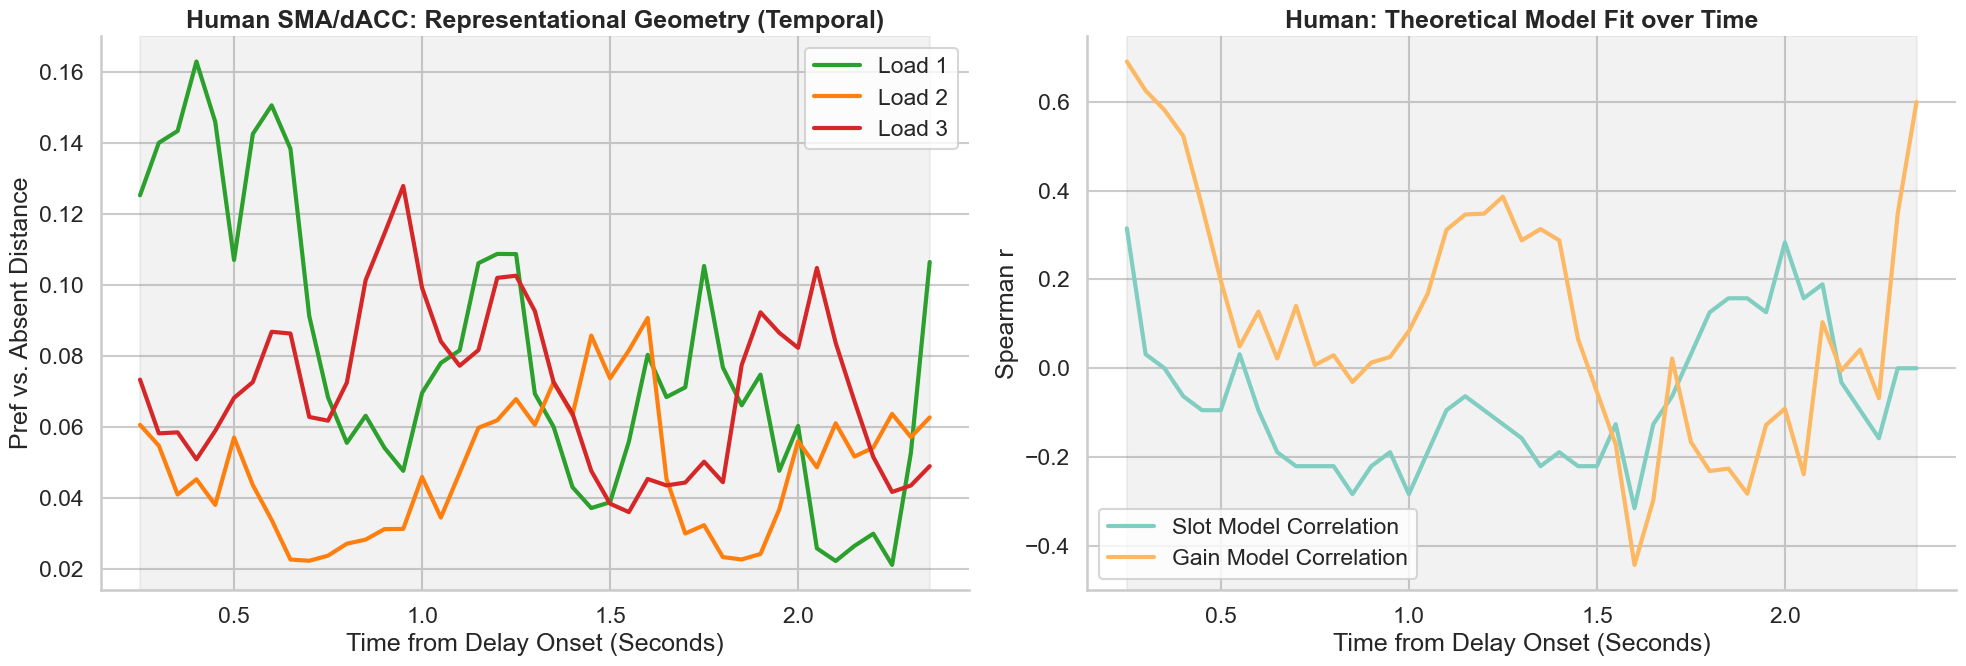

In [14]:
# ==========================================
# CELL 5: HUMAN TIME-RESOLVED RSA & STATS
# ==========================================
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

def create_human_model_rdms():
    """
    Builds the 6x6 Theoretical RDMs for Human RSA
    Conditions: [L1_Pres, L2_Pres, L3_Pres, L1_Abs, L2_Abs, L3_Abs]
    """
    # Slot: Representation strength is constant (1.0) regardless of load
    coords_slot = np.array([1.0, 1.0, 1.0, 0.0, 0.0, 0.0])
    
    # Gain: Representation strength degrades (compresses) as load increases
    coords_gain = np.array([1.0, 0.66, 0.33, 0.0, 0.0, 0.0])

    # Build distance matrices based on absolute difference in representational strength
    m_slot = np.abs(coords_slot[:, None] - coords_slot[None, :])
    m_gain = np.abs(coords_gain[:, None] - coords_gain[None, :])
    
    return m_slot, m_gain

def compute_human_pseudopop_correlation(cells_dict, time_bins):
    num_bins = len(time_bins)
    num_cells = len(cells_dict)
    
    m_slot, m_gain = create_human_model_rdms()
    i_upper, j_upper = np.triu_indices(6, k=1)
    
    master_rdms, hum_slot_corr, hum_gain_corr = [], [], []
    
    print(f"Computing Human Pseudopopulation Correlation RSA ({num_cells} cells, 6 Conditions)...")
    for t in tqdm(range(num_bins)):
        # 6 Conditions x N Cells
        pop_matrix = np.full((6, num_cells), np.nan)
        
        for n_idx, (cell_key, (X_trials, y_binned, loads, pref_id)) in enumerate(cells_dict.items()):
            meas_t = y_binned[:, t]
            
            # Did the preferred item appear anywhere in the sequence?
            is_present = np.any(X_trials == pref_id, axis=1)
            
            for l_idx, load_val in enumerate([1, 2, 3]):
                mask_pres = (loads == load_val) & is_present
                mask_abs  = (loads == load_val) & ~is_present
                
                if np.sum(mask_pres) > 0: pop_matrix[l_idx, n_idx] = np.mean(meas_t[mask_pres])
                if np.sum(mask_abs) > 0:  pop_matrix[l_idx + 3, n_idx] = np.mean(meas_t[mask_abs])
                    
        # Compute Correlation Distance (1 - Pearson) gracefully handling NaNs
        df = pd.DataFrame(pop_matrix.T) 
        corr_matrix = df.corr(method='pearson').values
        dist_matrix = 1.0 - corr_matrix 
        master_rdms.append(dist_matrix)
        
        # Correlate with Theoretical Models (Spearman)
        emp_vec = dist_matrix[i_upper, j_upper]
        valid = ~np.isnan(emp_vec)
        
        if np.sum(valid) > 3: # Need minimum points for a valid correlation
            s_corr, _ = stats.spearmanr(emp_vec[valid], m_slot[i_upper, j_upper][valid])
            g_corr, _ = stats.spearmanr(emp_vec[valid], m_gain[i_upper, j_upper][valid])
            hum_slot_corr.append(s_corr)
            hum_gain_corr.append(g_corr)
        else:
            hum_slot_corr.append(0)
            hum_gain_corr.append(0)
            
    return master_rdms, hum_slot_corr, hum_gain_corr

# --- EXECUTE HUMAN RSA ---
# Note: We assume tr_human_dict and human_time_bins are still in memory from Cell 1
hum_rdms, hum_slot_corr, hum_gain_corr = compute_human_pseudopop_correlation(tr_human_dict, human_time_bins)

# --- EXTRACT DISTANCES FOR PLOTTING ---
num_bins = len(human_time_bins)
# We extract the distance between Present and Absent for each load
dist_L1_hum = np.array([hum_rdms[t][0, 3] for t in range(num_bins)]) 
dist_L2_hum = np.array([hum_rdms[t][1, 4] for t in range(num_bins)])
dist_L3_hum = np.array([hum_rdms[t][2, 5] for t in range(num_bins)])

# --- PLOTTING ---
sns.set_theme(style="whitegrid", context="talk")
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Plot 1: Human Distances over Time
ax = axes[0]
ax.plot(human_time_bins, dist_L1_hum, color='#2ca02c', lw=3, label='Load 1')
ax.plot(human_time_bins, dist_L2_hum, color='#ff7f0e', lw=3, label='Load 2')
ax.plot(human_time_bins, dist_L3_hum, color='#d62728', lw=3, label='Load 3')
ax.set_title("Human SMA/dACC: Representational Geometry (Temporal)", fontweight='bold')
ax.set_xlabel("Time from Delay Onset (Seconds)")
ax.set_ylabel("Pref vs. Absent Distance")
ax.legend()
ax.axvspan(human_time_bins[0], human_time_bins[-1], color='grey', alpha=0.1)

# Plot 2: Human Model RDMs Spearman Correlation
ax2 = axes[1]
ax2.plot(human_time_bins, hum_slot_corr, color='#80CDC1', lw=3, label='Slot Model Correlation')
ax2.plot(human_time_bins, hum_gain_corr, color='#FDB863', lw=3, label='Gain Model Correlation')
ax2.set_title("Human: Theoretical Model Fit over Time", fontweight='bold')
ax2.set_xlabel("Time from Delay Onset (Seconds)")
ax2.set_ylabel("Spearman r")
ax2.legend()
ax2.axvspan(human_time_bins[0], human_time_bins[-1], color='grey', alpha=0.1)

sns.despine()
plt.tight_layout()
plt.savefig("Figure_4_Human_True_RSA.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [18]:
pd.DataFrame({
'load1': dist_L1_hum,
'load2': dist_L2_hum,
'load3': dist_L3_hum,
'human slot corr': hum_slot_corr,
'human gain corr': hum_gain_corr
}).to_csv('/Users/cwook/Documents/humac/output/human_results.csv')